# Graficos sumo

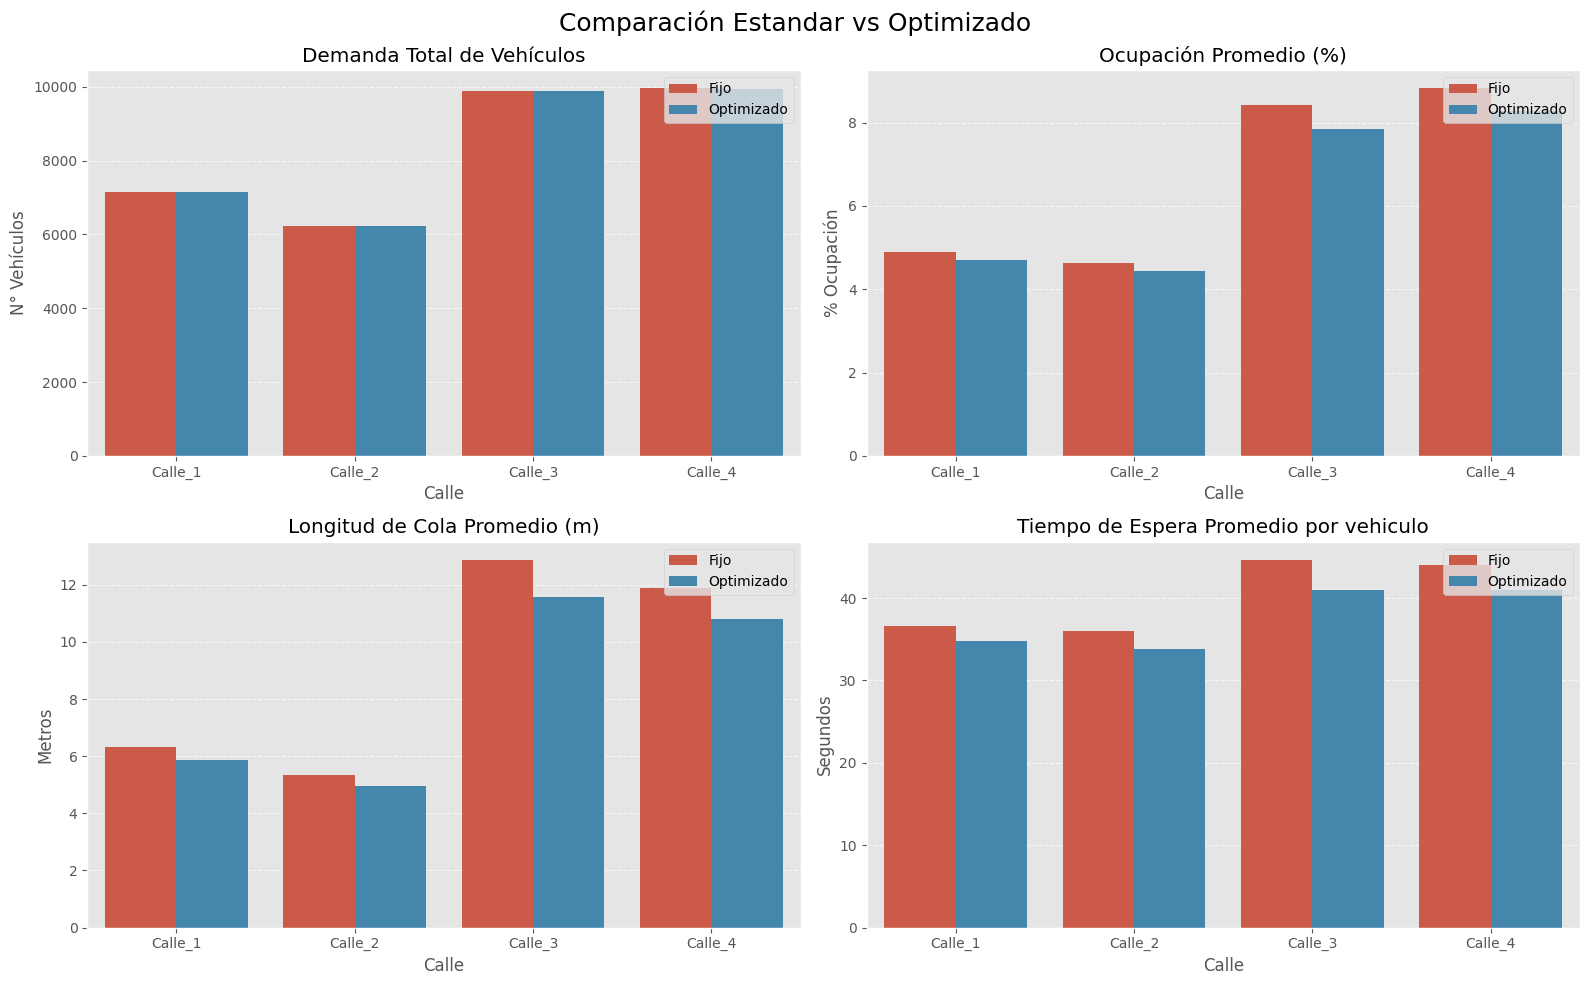

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

calles_base = {
    "Calle_1": ["calles_sumo/ocupacion11.xml", "calles_sumo/ocupacion12.xml"],
    "Calle_2": ["calles_sumo/ocupacion21.xml", "calles_sumo/ocupacion22.xml"],
    "Calle_3": ["calles_sumo/ocupacion31.xml", "calles_sumo/ocupacion32.xml"],
    "Calle_4": ["calles_sumo/ocupacion41.xml", "calles_sumo/ocupacion42.xml"],
}

calles_opt = {
    "Calle_1": ["calles_sumo_opt/ocupacion11.xml", "calles_sumo_opt/ocupacion12.xml"],
    "Calle_2": ["calles_sumo_opt/ocupacion21.xml", "calles_sumo_opt/ocupacion22.xml"],
    "Calle_3": ["calles_sumo_opt/ocupacion31.xml", "calles_sumo_opt/ocupacion32.xml"],
    "Calle_4": ["calles_sumo_opt/ocupacion41.xml", "calles_sumo_opt/ocupacion42.xml"],
}

def cargar_detector(path):
    return pd.read_xml(path, parser="etree")

def consolidar(config, etiqueta):
    data = []
    for calle, archivos in config.items():
        dfs = []
        for a in archivos:
            try:
                dfs.append(cargar_detector(a))
            except Exception as e:
                print(f"Error cargando {a}: {e}")
                continue
        
        if dfs:
            df = pd.concat(dfs, ignore_index=True)
            df["Calle"] = calle
            df["Configuracion"] = etiqueta
            data.append(df)

    return pd.concat(data, ignore_index=True)

df_fijo = consolidar(calles_base, "Fijo")
df_opt  = consolidar(calles_opt, "Optimizado")

df_total = pd.concat([df_fijo, df_opt], ignore_index=True)

resumen = df_total.groupby(
    ["Configuracion", "Calle"]
).agg(
    Demanda_Total=("nVehEntered", "sum"),
    Cola_Promedio=("maxJamLengthInMeters", "mean"),
    Ocupacion_Promedio=("meanOccupancy", "mean"),
    Espera_Promedio=("meanHaltingDuration", "mean") 
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparación Estandar vs Optimizado", fontsize=18)


ax_flat = axes.flatten()

sns.barplot(data=resumen, x="Calle", y="Demanda_Total", hue="Configuracion", ax=ax_flat[0])
ax_flat[0].set_title("Demanda Total de Vehículos")
ax_flat[0].set_ylabel("N° Vehículos")

sns.barplot(data=resumen, x="Calle", y="Ocupacion_Promedio", hue="Configuracion", ax=ax_flat[1])
ax_flat[1].set_title("Ocupación Promedio (%)")
ax_flat[1].set_ylabel("% Ocupación")

sns.barplot(data=resumen, x="Calle", y="Cola_Promedio", hue="Configuracion", ax=ax_flat[2])
ax_flat[2].set_title("Longitud de Cola Promedio (m)")
ax_flat[2].set_ylabel("Metros")

sns.barplot(data=resumen, x="Calle", y="Espera_Promedio", hue="Configuracion", ax=ax_flat[3])
ax_flat[3].set_title("Tiempo de Espera Promedio por vehiculo")
ax_flat[3].set_ylabel("Segundos")

for ax in ax_flat:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
